<a href="https://colab.research.google.com/github/Artemisa-00/AI-and-Python/blob/main/s101_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Improved s101 — Introduction to ML/DL with Python

**Original by:** Alan Badillo Salas  
**Improved & annotated for beginners**

---

## Pipeline Overview
```
1. Install & Import Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA)
4. Feature Engineering & Encoding
5. Train/Test Split  ← ADDED (was missing in original)
6. Scaling / Standardization
7. Visualize Correlations
8. Build & Train a Linear Regression Model
9. Evaluate the Model
10. (Bonus) From-Scratch Implementation for Learning
```

---
## SECTION 1 — Install & Import Libraries

### What and Why
We need external libraries that are not part of base Python:
- **numpy**: Mathematical operations on arrays (the engine under everything)
- **pandas**: Working with data tables (like Excel in Python)
- **matplotlib / seaborn**: Drawing charts to understand data
- **scikit-learn**: Industry-standard ML library (models, scaling, splitting, metrics)

### Best Practice
Always use short aliases (`np`, `pd`, `plt`, `sns`). This is the universal convention —
every textbook, tutorial, and Stack Overflow answer uses these exact aliases.

In [1]:
# Install required libraries (only needed once per environment)
%pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
# ✅ IMPROVED: Use standard short aliases (universal convention)
# Original used full names like 'pandas.read_csv()' — the world uses 'pd.read_csv()'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules (we import as needed below for clarity)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# ✅ ADDED: Set a random seed for reproducibility
# Without this, results change every time you run the notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ✅ ADDED: Make plots look nicer by default
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 4)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## SECTION 2 — Load the Dataset

### Dataset: Student Habits & Performance
Each row = one student. Each column = one characteristic.

**Goal:** Predict `exam_score` (y) from the other columns (X).

### What `.head()` and `.info()` tell us
- `.head(5)` → shows the first 5 rows so we can sanity-check the data loaded correctly
- `.info()` → shows column names, data types, and whether any values are missing (non-null count)

In [3]:
# Load the dataset from GitHub
# In production, you'd load from a local file or a database
DATA_URL = "https://raw.githubusercontent.com/dragonnomada/ia-cic-abril-2026/refs/heads/main/conjuntos/student_habits_performance.csv"

# pd.read_csv() downloads and parses the CSV into a DataFrame (table)
students = pd.read_csv(DATA_URL)

print(f"✅ Dataset loaded: {students.shape[0]} students, {students.shape[1]} columns")
# .shape returns (rows, columns) — like checking the dimensions of a spreadsheet

# Show the first 5 rows to verify it loaded correctly
students.head()

✅ Dataset loaded: 1000 students, 16 columns


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
# .info() is the first thing you should always run on a new dataset
# It shows:
#   - Column names
#   - How many non-null values each column has (null = missing = problem)
#   - Data type: int64 (integer), float64 (decimal), object (text/string)
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

---
## SECTION 3 — Exploratory Data Analysis (EDA)

EDA = **understanding your data before modeling**. Never skip this step.

### Key questions to answer:
1. Are there missing values?
2. What is the range of each column?
3. Are there outliers?
4. What is the distribution shape?
5. Are categorical columns balanced?

### ✅ IMPROVED: Using descriptive variable names
Original used e1, e2, ..., e15 (confusing after 5 minutes).  
We use the actual column names — self-documenting code.

In [5]:
# ── 3.1 Summary Statistics ─────────────────────────────────────────────────
# .describe() gives you 8 statistics for every NUMERICAL column:
#   count  → how many non-null values (if < total rows, you have missing data)
#   mean   → average
#   std    → standard deviation (how spread out values are)
#   min    → smallest value
#   25%    → first quartile (25% of students scored below this)
#   50%    → median (the middle student)
#   75%    → third quartile (75% of students scored below this)
#   max    → largest value
students.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [6]:
# ── 3.2 Check for Missing Values ───────────────────────────────────────────
# .isnull().sum() counts how many NaN (missing) values each column has
# If any column shows a number > 0, we need to handle it (fill or drop)
missing_values = students.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0] if missing_values.any() else "✅ No missing values found!")

Missing values per column:
parental_education_level    91
dtype: int64


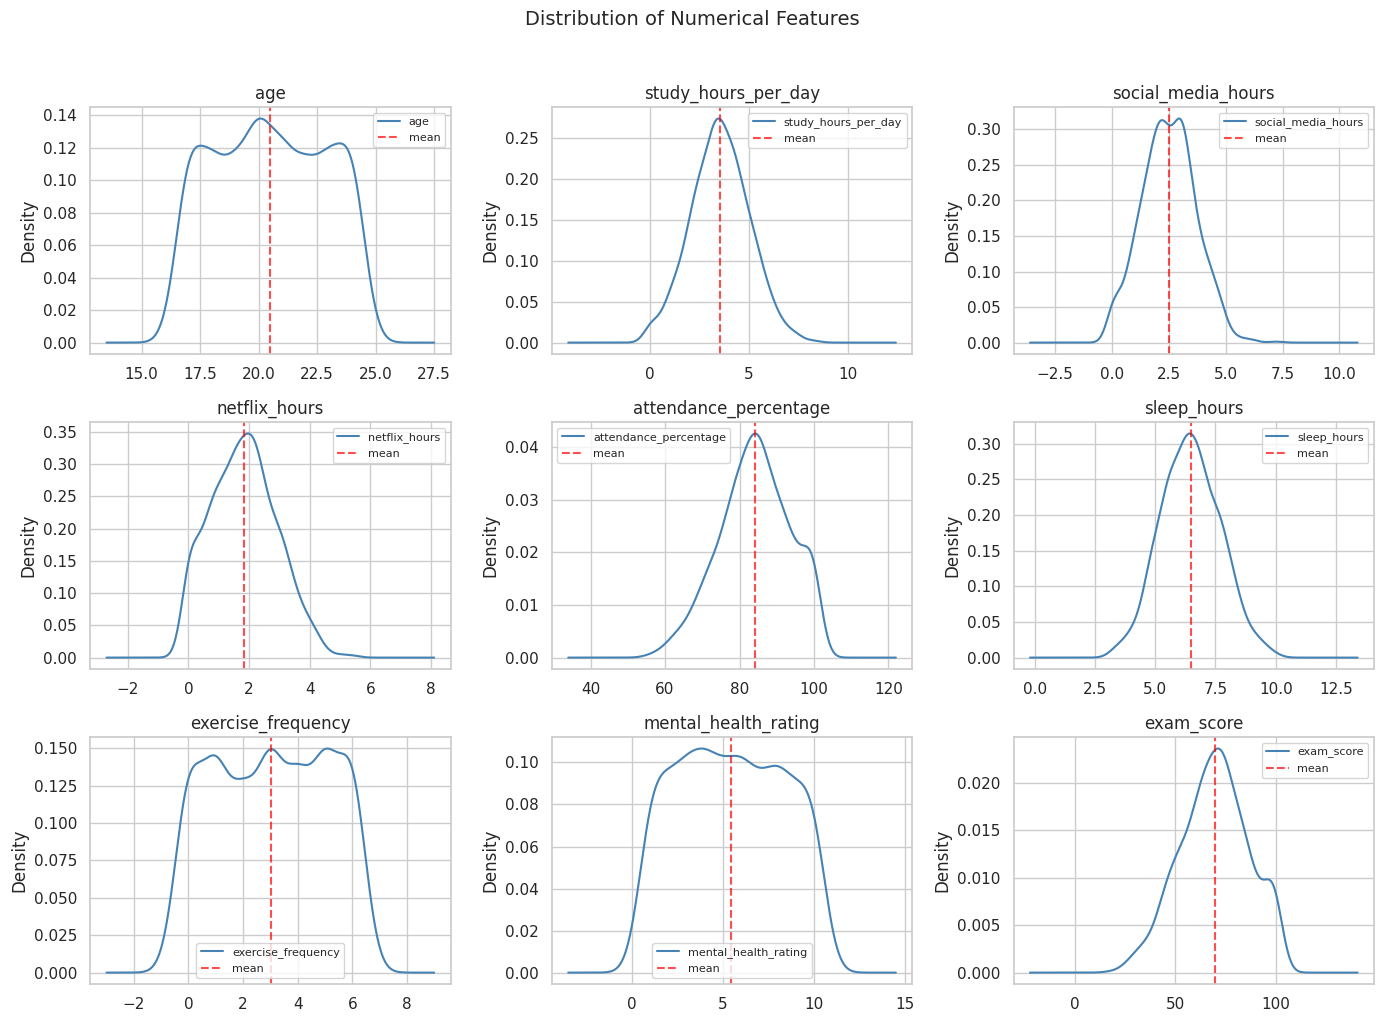

In [7]:
# ── 3.3 Explore Numerical Features ─────────────────────────────────────────
# We define which columns are numerical (continuous) vs categorical (text)
# This matters because each type needs different treatment

NUMERICAL_COLS = [
    'age', 'study_hours_per_day', 'social_media_hours',
    'netflix_hours', 'attendance_percentage', 'sleep_hours',
    'exercise_frequency', 'mental_health_rating', 'exam_score'
]

CATEGORICAL_COLS = [
    'gender', 'part_time_job', 'diet_quality',
    'parental_education_level', 'internet_quality', 'extracurricular_participation'
]

TARGET_COL = 'exam_score'  # What we want to predict

# Plot distributions of numerical features
# Density plot (KDE) = smoothed histogram showing the 'shape' of the data
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()  # Convert 2D grid to 1D list for easy looping

for i, col in enumerate(NUMERICAL_COLS):
    students[col].plot.density(ax=axes[i], title=col, color='steelblue')
    axes[i].axvline(students[col].mean(), color='red', linestyle='--', alpha=0.7, label='mean')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# A bell-shaped (Gaussian) distribution is common and ideal for linear models
# Skewed distributions or outliers may need special treatment

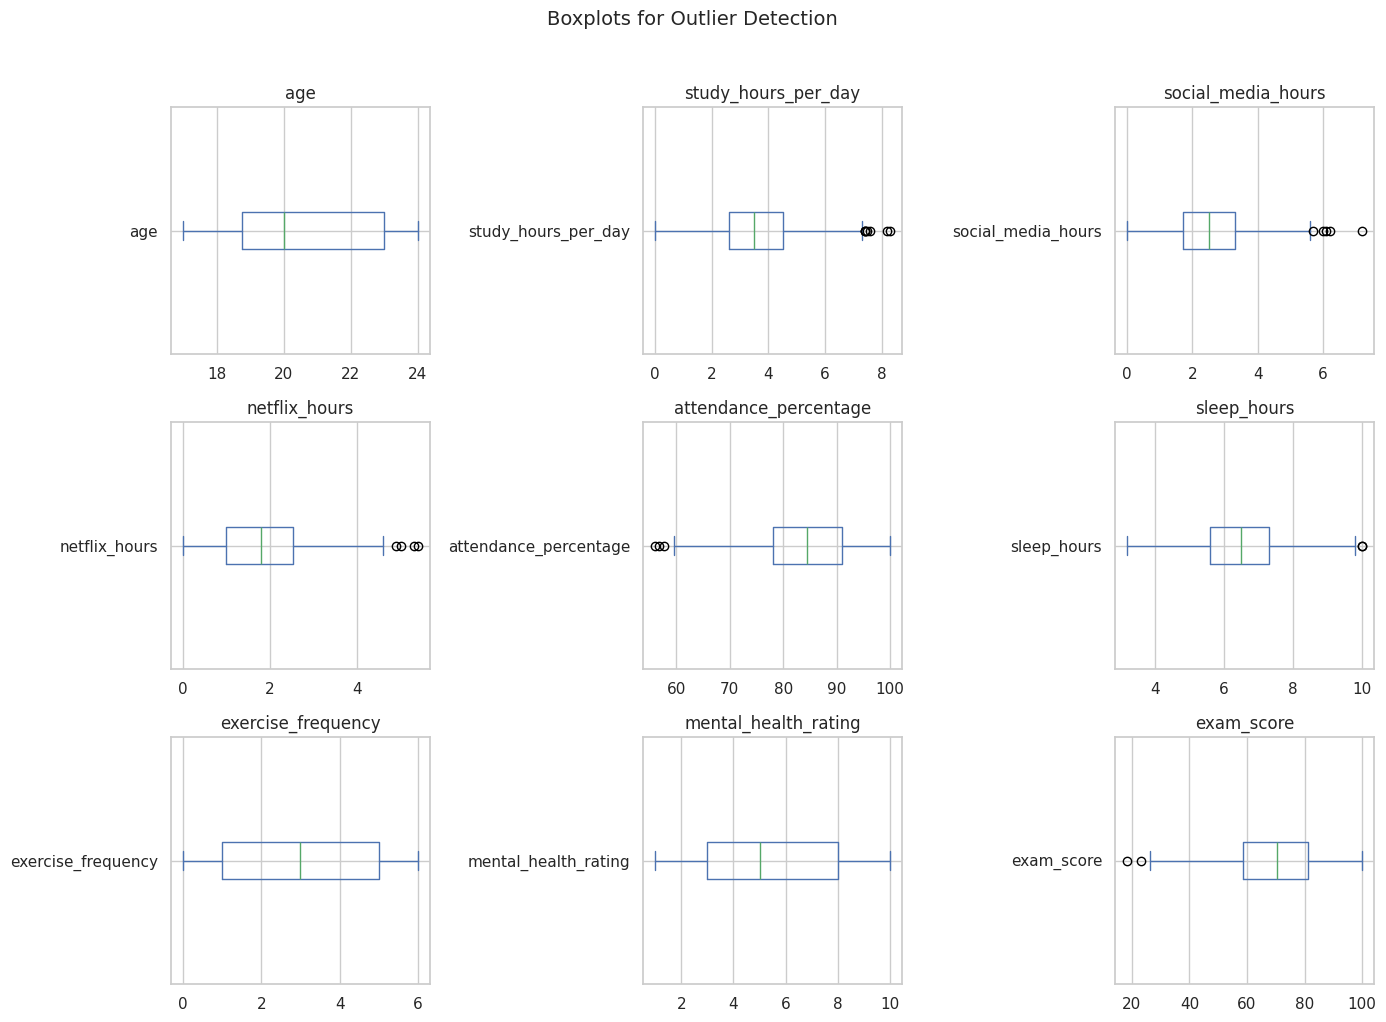

In [8]:
# ── 3.4 Boxplots for Outlier Detection ─────────────────────────────────────
# A boxplot shows:
#   - Box: middle 50% of data (Q1 to Q3)
#   - Line in box: median
#   - Whiskers: 1.5 × IQR beyond Q1 and Q3
#   - Dots outside whiskers: OUTLIERS

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    students[col].plot.box(ax=axes[i], vert=False)
    axes[i].set_title(col)

plt.suptitle('Boxplots for Outlier Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

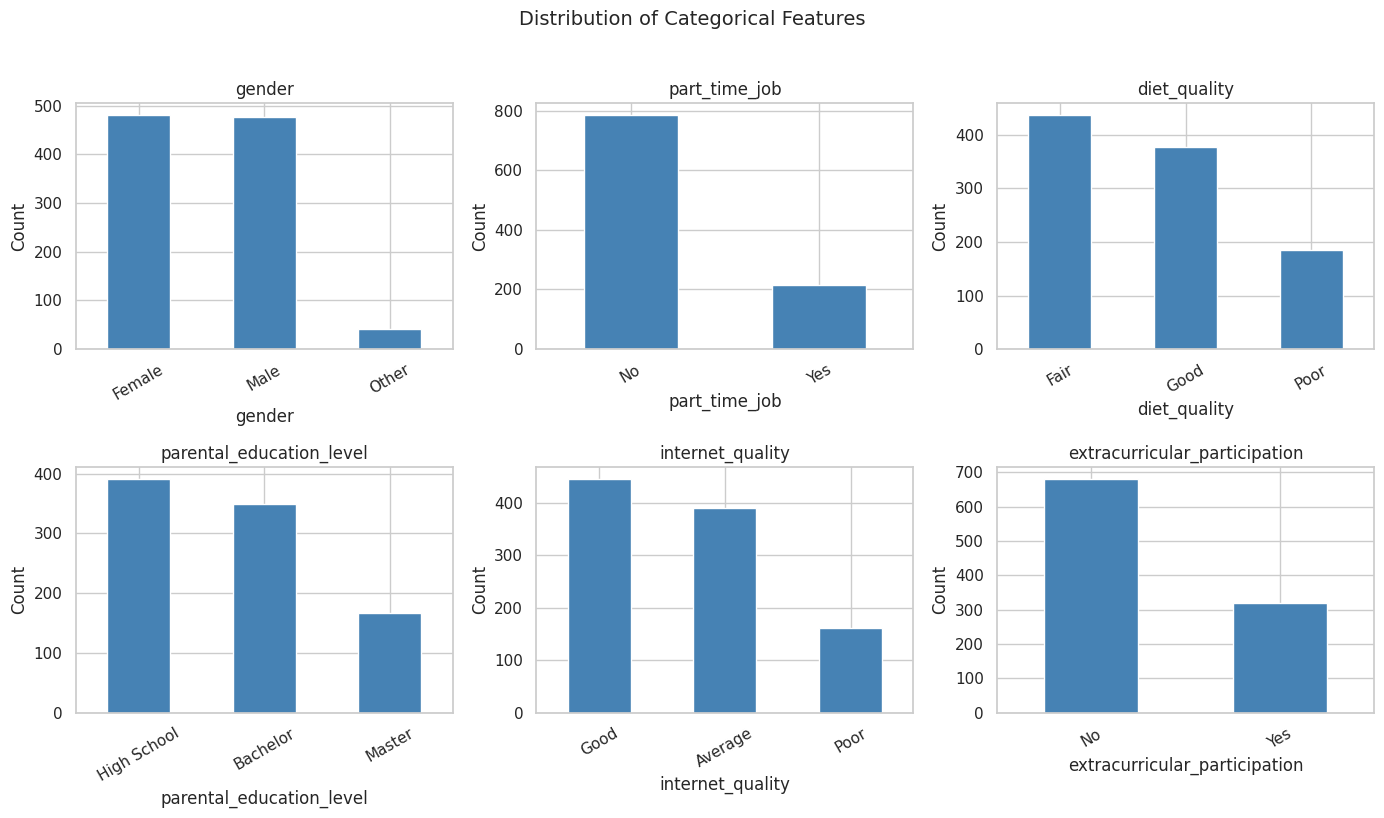


── gender ──
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64

── part_time_job ──
part_time_job
No     785
Yes    215
Name: count, dtype: int64

── diet_quality ──
diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64

── parental_education_level ──
parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64

── internet_quality ──
internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64

── extracurricular_participation ──
extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64


In [9]:
# ── 3.5 Categorical Feature Analysis ──────────────────────────────────────
# For text columns, .value_counts() shows how many times each category appears
# We want balanced categories — extreme imbalance can bias the model

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    counts = students[col].value_counts()
    counts.plot.bar(ax=axes[i], title=col, color='steelblue', edgecolor='white')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribution of Categorical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print value counts for each categorical column
for col in CATEGORICAL_COLS:
    print(f"\n── {col} ──")
    print(students[col].value_counts())

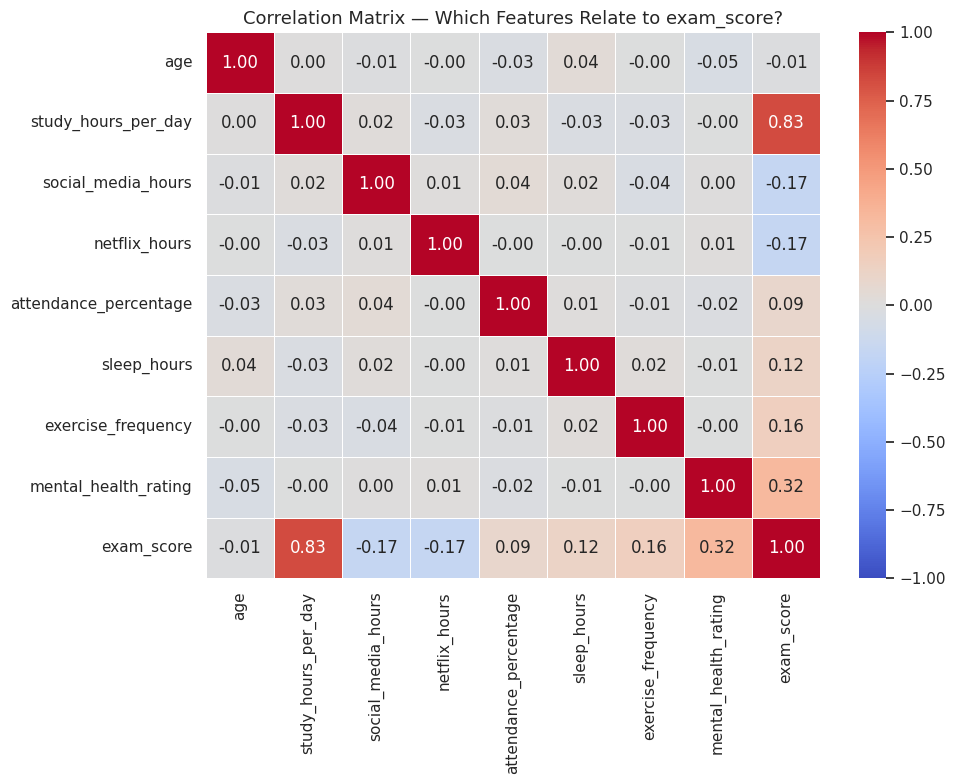


Correlations with exam_score (sorted):
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


In [10]:
# ── 3.6 Correlation Heatmap ─────────────────────────────────────────────────
# Correlation measures how much two variables move together:
#   +1 = perfect positive relationship (as X goes up, Y goes up)
#    0 = no linear relationship
#   -1 = perfect negative relationship (as X goes up, Y goes down)
#
# This helps us understand which features are most likely to predict exam_score

plt.figure(figsize=(10, 8))
corr_matrix = students[NUMERICAL_COLS].corr()  # Compute pairwise correlations

sns.heatmap(
    corr_matrix,
    annot=True,        # Show correlation numbers inside each cell
    fmt='.2f',         # Format to 2 decimal places
    cmap='coolwarm',   # Blue = negative, Red = positive correlation
    vmin=-1, vmax=1,   # Fix color scale
    linewidths=0.5
)
plt.title('Correlation Matrix — Which Features Relate to exam_score?', fontsize=13)
plt.tight_layout()
plt.show()

# Look at the 'exam_score' row/column to see which features correlate most with the target
print("\nCorrelations with exam_score (sorted):")
print(corr_matrix['exam_score'].sort_values(ascending=False))

---
## SECTION 4 — Feature Engineering & Encoding

ML algorithms **can only process numbers**. We need to convert text categories to numbers.

### Encoding Strategies:

| Situation | Method | Example |
|-----------|--------|---------|
| Yes/No column | Binary (0/1) | part_time_job: Yes→1, No→0 |
| Ordered categories | Ordinal encoding | Poor=0, Fair=1, Good=2 |
| Unordered categories | One-Hot encoding | Gender→ is_male, is_other |

### ✅ IMPROVED: Consistent ordinal scales and descriptive variable names

In [11]:
# ── 4.1 Copy the dataset to avoid modifying the original ───────────────────
# Always work on a copy — this preserves the original in case you need to go back
df = students.copy()

# ── 4.2 Binary Encoding (Yes/No columns) ──────────────────────────────────
# (column == "Yes") creates True/False → .astype(int) converts to 1/0
# Analogy: converting a light switch state (on/off) to a number (1/0)
df['part_time_job'] = (df['part_time_job'] == 'Yes').astype(int)
df['extracurricular_participation'] = (df['extracurricular_participation'] == 'Yes').astype(int)

print("Binary encoding:")
print(df[['part_time_job', 'extracurricular_participation']].value_counts())

Binary encoding:
part_time_job  extracurricular_participation
0              0                                531
               1                                254
1              0                                151
               1                                 64
Name: count, dtype: int64


In [12]:
# ── 4.3 Ordinal Encoding (ordered categories) ──────────────────────────────
# For categories with a clear order: Poor < Fair < Good
# We use CONSISTENT spacing (0, 1, 2) instead of (-1, 0, 1) or (-2, 1, 2)
# Consistent spacing = equal 'distance' between each level — more honest mathematically

# ✅ IMPROVED: Consistent 0-1-2 scale (not -1/0/1 or -2/1/2 like the original)
diet_quality_map = {'Poor': 0, 'Fair': 1, 'Good': 2}
internet_quality_map = {'Poor': 0, 'Average': 1, 'Good': 2}  # ✅ Fixed inconsistent scale
education_level_map = {'High School': 0, 'Bachelor': 1, 'Master': 2}  # ✅ Fixed arbitrary 1/2/4

df['diet_quality'] = df['diet_quality'].map(diet_quality_map)
df['internet_quality'] = df['internet_quality'].map(internet_quality_map)

# ✅ IMPROVED: Fill missing parental education with the MEDIAN, not an arbitrary 1.5
df['parental_education_level'] = df['parental_education_level'].map(education_level_map)
median_education = df['parental_education_level'].median()
df['parental_education_level'] = df['parental_education_level'].fillna(median_education)

print("Ordinal encoding complete. Sample values:")
print(df[['diet_quality', 'internet_quality', 'parental_education_level']].head())

Ordinal encoding complete. Sample values:
   diet_quality  internet_quality  parental_education_level
0             1                 1                       2.0
1             2                 1                       0.0
2             0                 0                       0.0
3             0                 2                       2.0
4             1                 2                       2.0


In [13]:
# ── 4.4 One-Hot Encoding for Gender ────────────────────────────────────────
# Gender has 3 categories: Male, Female, Other
# We CANNOT encode as 1/2/3 (that falsely implies Male < Female < Other)
# Instead, we create binary columns — one per category
#
# With drop_first=True we only need 2 columns (not 3) to represent 3 categories
# because if is_male=0 and is_other=0 → the student must be Female
# This avoids the 'dummy variable trap' (multicollinearity)

gender_dummies = pd.get_dummies(df['gender'], prefix='gender', drop_first=True, dtype=int)
# ✅ pd.get_dummies() is cleaner than manually doing (col == 'Male').astype(int)

print("Gender one-hot encoding:")
print(pd.concat([df['gender'], gender_dummies], axis=1).head(10))

# Add the dummy columns to the main dataframe and drop the original text column
df = pd.concat([df, gender_dummies], axis=1)
df = df.drop(columns=['gender'])

Gender one-hot encoding:
   gender  gender_Male  gender_Other
0  Female            0             0
1  Female            0             0
2    Male            1             0
3  Female            0             0
4  Female            0             0
5    Male            1             0
6  Female            0             0
7  Female            0             0
8  Female            0             0
9  Female            0             0


In [14]:
# ── 4.5 Define Feature Matrix X and Target Vector y ────────────────────────
# X = all the input columns (what we use to predict)
# y = the target column (what we want to predict)
#
# ✅ IMPROVED: Explicitly list feature columns (self-documenting, easy to modify)
# Original used .T trick which is fragile and hard to read

FEATURE_COLS = [
    'age',
    'gender_Male', 'gender_Other',        # One-hot encoded gender
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'part_time_job',
    'attendance_percentage',
    'sleep_hours',
    'diet_quality',
    'exercise_frequency',
    'parental_education_level',
    'internet_quality',
    'mental_health_rating',
    'extracurricular_participation'
]

X = df[FEATURE_COLS]  # Feature matrix: shape (n_students, n_features)
y = df[TARGET_COL]    # Target vector: shape (n_students,)

print(f"Feature matrix X: {X.shape}")
print(f"Target vector y: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")
X.head()

Feature matrix X: (1000, 15)
Target vector y: (1000,)

Features: ['age', 'gender_Male', 'gender_Other', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']


,age,gender_Male,gender_Other,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
0,23,0,0,0.0,1.2,1.1,0,85.0,8.0,1,6,2.0,1,8,1
1,20,0,0,6.9,2.8,2.3,0,97.3,4.6,2,6,0.0,1,8,0
2,21,1,0,1.4,3.1,1.3,0,94.8,8.0,0,1,0.0,0,1,0
3,23,0,0,1.0,3.9,1.0,0,71.0,9.2,0,4,2.0,2,1,1
4,19,0,0,5.0,4.4,0.5,0,90.9,4.9,1,3,2.0,2,1,0


---
## SECTION 5 — Train/Test Split ← CRITICAL (was MISSING in original)

### Why is this non-negotiable?
If you train AND test on the same data, your model might **memorize** the training data
instead of **learning** patterns. This is called **overfitting**.

**Analogy:** Imagine a student who memorizes exact exam questions instead of learning the concepts.
They'd score 100% on the same exam, but fail a new version of it.

The **test set** simulates "new, unseen students" — data the model has never seen.
Only by evaluating on the test set can we know if the model truly generalizes.

### Standard split: 80% training, 20% testing

In [15]:
# ── 5.1 Split into Training and Testing Sets ────────────────────────────────
# test_size=0.2  → 20% of data goes to the test set
# random_state=42 → 'shuffle seed' so the split is the same every time you run
#                   (42 is a common convention — any number works)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Training set:  {X_train.shape[0]} students ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]} students ({X_test.shape[0]/len(X)*100:.0f}%)")

# RULE: After this split, you must:
#   - FIT (train) the scaler and model ONLY on X_train, y_train
#   - APPLY (transform) to X_test, y_test
# Never let test data influence training — that would be 'data leakage'

Training set:  800 students (80%)
Test set:      200 students (20%)


---
## SECTION 6 — Scaling / Standardization

### What is StandardScaler?
For each feature, it computes: `x_scaled = (x - mean) / std`

After scaling:
- Mean of each column = 0
- Standard deviation of each column = 1

**Analogy:** Converting temperatures from Celsius/Fahrenheit to a universal scale.
A Brazilian and a Canadian can now compare '20°C' and '68°F' on the same standard scale.

### Why scale ONLY on training data?
If we computed the mean/std using the test data too, we'd be 'peeking' at test information
during training — a form of data leakage. The scaler must learn ONLY from training data.

In [16]:
# ── 6.1 Fit and Apply StandardScaler ────────────────────────────────────────
# .fit_transform(X_train): compute mean & std FROM training data, then scale training data
# .transform(X_test):      use the SAME mean & std to scale test data (do NOT re-fit!)

scaler_X = StandardScaler()

# ✅ IMPROVED: Fit only on training data, then apply to both sets
X_train_scaled = scaler_X.fit_transform(X_train)  # Learn mean/std AND scale
X_test_scaled  = scaler_X.transform(X_test)        # Only scale (use training mean/std)

# Convert back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)

# ✅ IMPROVED: Use StandardScaler for y too (consistent approach)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

print("After scaling (training data):")
print(f"  Mean of study_hours_per_day: {X_train_scaled['study_hours_per_day'].mean():.6f} (should be ~0)")
print(f"  Std  of study_hours_per_day: {X_train_scaled['study_hours_per_day'].std():.6f}  (should be ~1)")
X_train_scaled.describe()

After scaling (training data):
  Mean of study_hours_per_day: -0.000000 (should be ~0)
  Std  of study_hours_per_day: 1.000626  (should be ~1)


,age,gender_Male,gender_Other,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
count,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02
mean,-2.309264e-16,4.440892e-17,-3.219647e-17,-8.437695e-17,9.992007e-17,1.243450e-16,-8.881784e-18,-6.084022e-16,5.684342e-16,8.881784e-17,-4.440892e-17,-3.552714e-17,7.327472e-17,-1.221245e-16,3.108624e-17
std,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00
min,-1.513996e+00,-9.393364e-01,-2.138963e-01,-2.397500e+00,-2.129109e+00,-1.667822e+00,-5.233406e-01,-3.003096e+00,-2.664668e+00,-1.639658e+00,-1.524587e+00,-1.078639e+00,-1.786784e+00,-1.566166e+00,-6.899382e-01
25%,-6.448201e-01,-9.393364e-01,-2.138963e-01,-7.128567e-01,-6.725758e-01,-7.518137e-01,-5.233406e-01,-6.224172e-01,-7.058784e-01,-2.603452e-01,-1.027777e+00,-1.078639e+00,-3.935801e-01,-8.642429e-01,-6.899382e-01
50%,-2.102320e-01,-9.393364e-01,-2.138963e-01,-3.899949e-02,1.285177e-02,-1.900717e-02,-5.233406e-01,3.120655e-02,-5.294853e-02,-2.603452e-01,-3.415573e-02,3.221908e-01,-3.935801e-01,-1.623197e-01,-6.899382e-01
75%,1.093532e+00,1.064581e+00,-2.138963e-01,6.348577e-01,6.982794e-01,7.137993e-01,-5.233406e-01,7.273424e-01,6.815976e-01,1.118967e+00,9.594654e-01,3.221908e-01,9.996239e-01,8.905650e-01,1.449405e+00
max,1.528120e+00,1.064581e+00,4.675162e+00,3.195515e+00,4.039739e+00,3.278622e+00,1.910802e+00,1.673237e+00,2.885236e+00,1.118967e+00,1.456276e+00,1.723020e+00,9.996239e-01,1.592488e+00,1.449405e+00


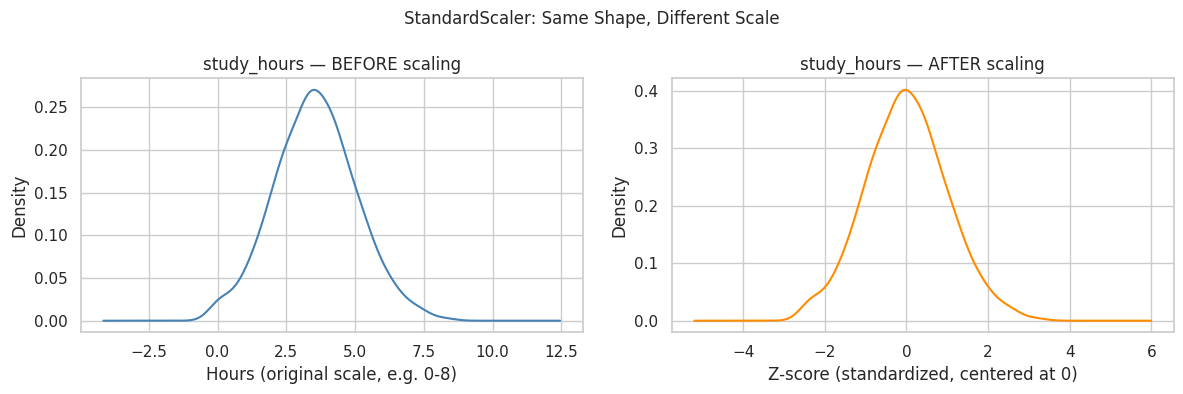

In [17]:
# ── 6.2 Visualize Before vs After Scaling ──────────────────────────────────
# The SHAPE of the distribution doesn't change — only the scale (axis values)
# This is an important concept: scaling doesn't distort your data

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

X_train['study_hours_per_day'].plot.density(ax=axes[0], color='steelblue')
axes[0].set_title('study_hours — BEFORE scaling')
axes[0].set_xlabel('Hours (original scale, e.g. 0-8)')

X_train_scaled['study_hours_per_day'].plot.density(ax=axes[1], color='darkorange')
axes[1].set_title('study_hours — AFTER scaling')
axes[1].set_xlabel('Z-score (standardized, centered at 0)')

plt.suptitle('StandardScaler: Same Shape, Different Scale', fontsize=12)
plt.tight_layout()
plt.show()

---
## SECTION 7 — Visualize Feature-Target Correlations

Before training, visualize how each key feature relates to the target (exam_score).
This confirms our intuitions (e.g., more study → higher score) and helps identify
which features are most informative.

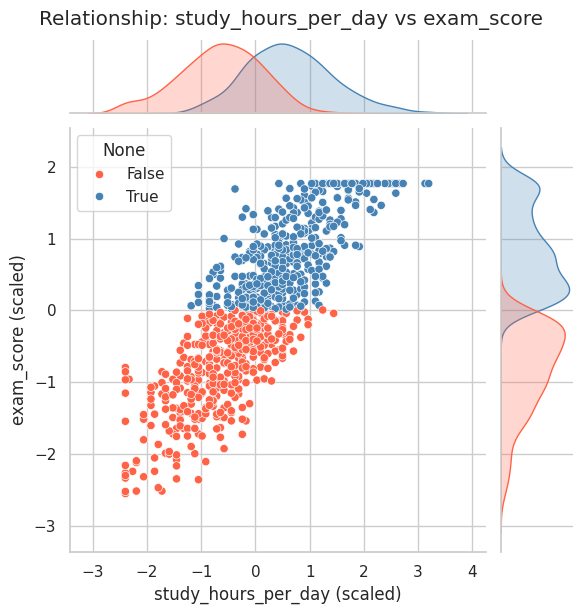

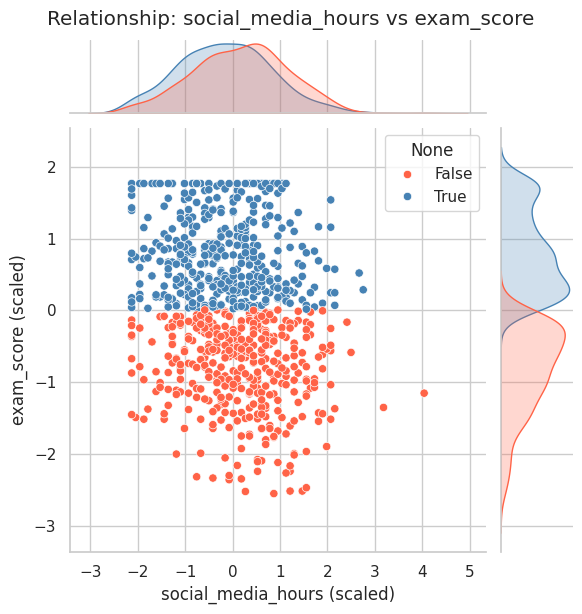

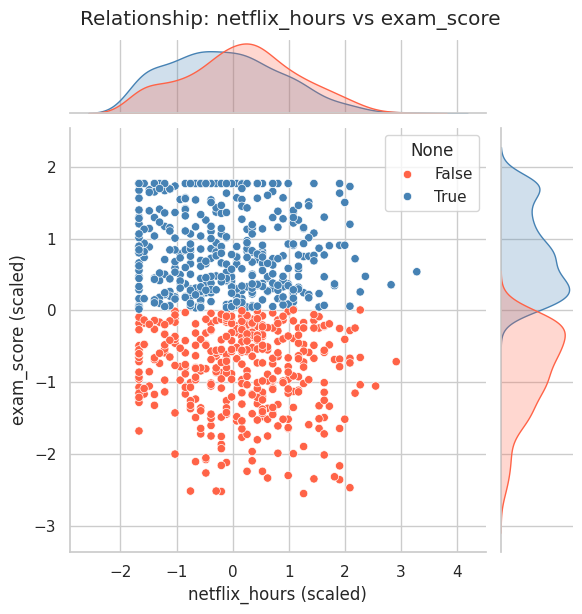

In [24]:
# ── 7.1 Joint Plots: Feature vs Target ─────────────────────────────────────
key_features = ['study_hours_per_day', 'social_media_hours', 'netflix_hours']

# ✅ FIX: Convertir a Series con índice alineado para evitar el ValueError
# Ambos deben tener el mismo origen (X_train_scaled e y_train deben venir
# del mismo train_test_split)
y_plot = pd.Series(y_train_scaled.values if hasattr(y_train_scaled, 'values') else y_train_scaled,
                   index=X_train_scaled.index,
                   name='exam_score')

y_pass = pd.Series(y_train.values if hasattr(y_train, 'values') else y_train,
                   index=X_train_scaled.index)

for feature in key_features:
    g = sns.jointplot(
        x=X_train_scaled[feature],
        y=y_plot,
        hue=(y_pass >= 70),
        palette=['tomato', 'steelblue']
    )
    g.set_axis_labels(f'{feature} (scaled)', 'exam_score (scaled)')
    g.figure.suptitle(f'Relationship: {feature} vs exam_score', y=1.02)
    plt.show()

---
## SECTION 8 — Linear Regression Model

### The Formula
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_k x_k$$

- **β₀ (beta_0)**: intercept — the predicted score if all features were 0
- **βᵢ (beta_i)**: coefficient — how much exam_score changes when feature xᵢ increases by 1
- **ŷ (y-hat)**: the model's prediction

### Approach A: sklearn LinearRegression (Production-Ready)
This uses the mathematically optimal 'Normal Equation' solution — exact, instant, and reliable.

### Approach B: From-Scratch with Gradient Descent (Educational)
Implemented later so you can see HOW the model learns.

In [25]:
# ── 8A. Sklearn Linear Regression (Recommended Approach) ───────────────────
# This is the correct, production-ready way to do linear regression in Python
# It finds the OPTIMAL coefficients in one computation (Normal Equation)
# No need for 100,000 random iterations!

model = LinearRegression()

# .fit() = 'train the model' = find the best beta values
# RULE: Only fit on TRAINING data
model.fit(X_train_scaled, y_train_scaled)

print("✅ Model trained!")
print(f"\nIntercept (β₀): {model.intercept_:.4f}")
print("\nCoefficients (βᵢ):")

# Display coefficients with feature names — this is much more informative than
# a raw array of 15 numbers with no context
coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient (β)': model.coef_
}).sort_values('Coefficient (β)', ascending=False)

print(coef_df.to_string(index=False))
print("\nInterpretation: A POSITIVE β means this feature increases exam_score.")
print("                A NEGATIVE β means this feature decreases exam_score.")

✅ Model trained!

Intercept (β₀): 0.0000

Coefficients (βᵢ):
                      Feature  Coefficient (β)
          study_hours_per_day         0.829003
         mental_health_rating         0.325909
           exercise_frequency         0.154950
                  sleep_hours         0.141905
        attendance_percentage         0.079991
                part_time_job         0.009149
                 gender_Other         0.008315
                          age         0.007308
                  gender_Male         0.003330
     parental_education_level        -0.001559
extracurricular_participation        -0.004389
             internet_quality        -0.004714
                 diet_quality        -0.013797
                netflix_hours        -0.148148
           social_media_hours        -0.184982

Interpretation: A POSITIVE β means this feature increases exam_score.
                A NEGATIVE β means this feature decreases exam_score.


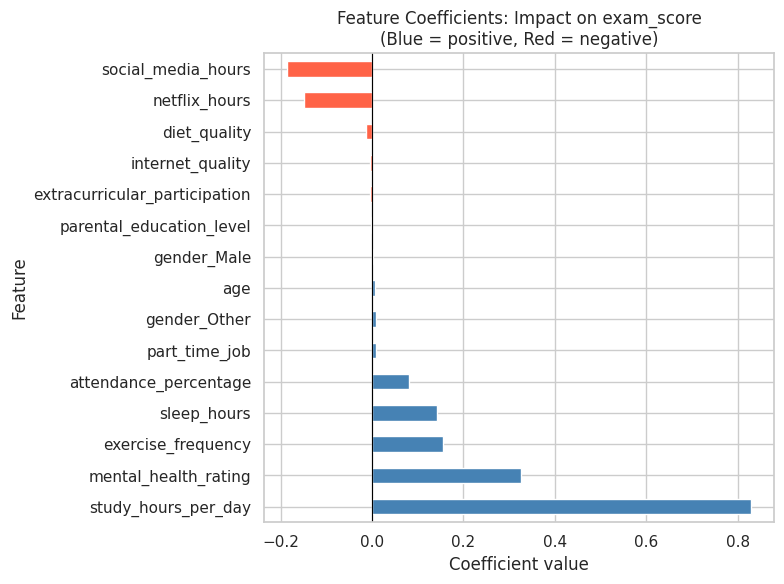

In [26]:
# ── 8A.2 Visualize Coefficient Importance ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['Coefficient (β)']]
coef_df.plot.barh(x='Feature', y='Coefficient (β)', ax=ax, color=colors, legend=False)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Coefficients: Impact on exam_score\n(Blue = positive, Red = negative)', fontsize=12)
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

---
## SECTION 9 — Evaluate the Model

### Key Metrics

| Metric | Formula | Meaning |
|--------|---------|--------|
| **MSE** | mean((y - ŷ)²) | Average squared error |
| **RMSE** | √MSE | Average error in original units |
| **MAE** | mean(|y - ŷ|) | Average absolute error |
| **R²** | 1 - SSres/SStot | % of variance explained by model |

**R² (R-squared)**: A value between 0 and 1.  
- R²=1 → perfect predictions  
- R²=0 → model is no better than predicting the mean every time  
- R²=0.7 → the model explains 70% of the variability in exam scores

In [27]:
# ── 9.1 Generate Predictions on TEST SET ──────────────────────────────────
# RULE: Always evaluate on data the model has NEVER seen (test set)
# Evaluating on training data would be like grading your own homework — cheating!

y_pred_scaled = model.predict(X_test_scaled)  # Predictions (scaled)

# Denormalize: convert predictions back to original exam score units (0-100)
# Inverse formula: y_original = y_scaled × std + mean
y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_test_original = y_test.values  # Already in original scale

print("Sample predictions vs actual scores:")
comparison = pd.DataFrame({
    'Actual exam_score': y_test_original[:10],
    'Predicted exam_score': y_pred_original[:10],
    'Error': y_test_original[:10] - y_pred_original[:10]
})
print(comparison.round(2).to_string())

Sample predictions vs actual scores:
   Actual exam_score  Predicted exam_score  Error
0               64.2                 66.05  -1.85
1               72.7                 74.81  -2.11
2               79.0                 78.63   0.37
3               79.5                 73.81   5.69
4               58.2                 61.49  -3.29
5               53.4                 54.52  -1.12
6               70.8                 75.42  -4.62
7               62.5                 55.49   7.01
8               36.8                 41.14  -4.34
9               67.6                 72.34  -4.74


In [28]:
# ── 9.2 Compute All Evaluation Metrics ─────────────────────────────────────
errors = y_test_original - y_pred_original

# Manual calculation (transparent, matches sklearn)
SSE  = (errors ** 2).sum()
MSE  = (errors ** 2).mean()
RMSE = MSE ** 0.5
SAE  = np.abs(errors).sum()
MAE  = np.abs(errors).mean()

# ✅ ADDED: R² score — not present in the original notebook, but essential
# R² = how much of the variance in exam_score our model explains
R2 = metrics.r2_score(y_test_original, y_pred_original)

results = pd.DataFrame({
    'Metric': ['N', 'SSE', 'MSE', 'RMSE', 'MAE', 'R²'],
    'Value': [len(errors), SSE, MSE, RMSE, MAE, R2],
    'Interpretation': [
        f'{len(errors)} test students',
        f'Total squared error: {SSE:.2f}',
        f'Average squared error: {MSE:.2f}',
        f'Average error: ±{RMSE:.2f} points',   # Most interpretable for exam scores
        f'Average abs error: ±{MAE:.2f} points',
        f'Model explains {R2*100:.1f}% of score variance'
    ]
})
print(results.to_string(index=False))

Metric       Value                         Interpretation
     N  200.000000                      200 test students
   SSE 5183.872377           Total squared error: 5183.87
   MSE   25.919362           Average squared error: 25.92
  RMSE    5.091106            Average error: ±5.09 points
   MAE    4.139449        Average abs error: ±4.14 points
    R²    0.898922 Model explains 89.9% of score variance


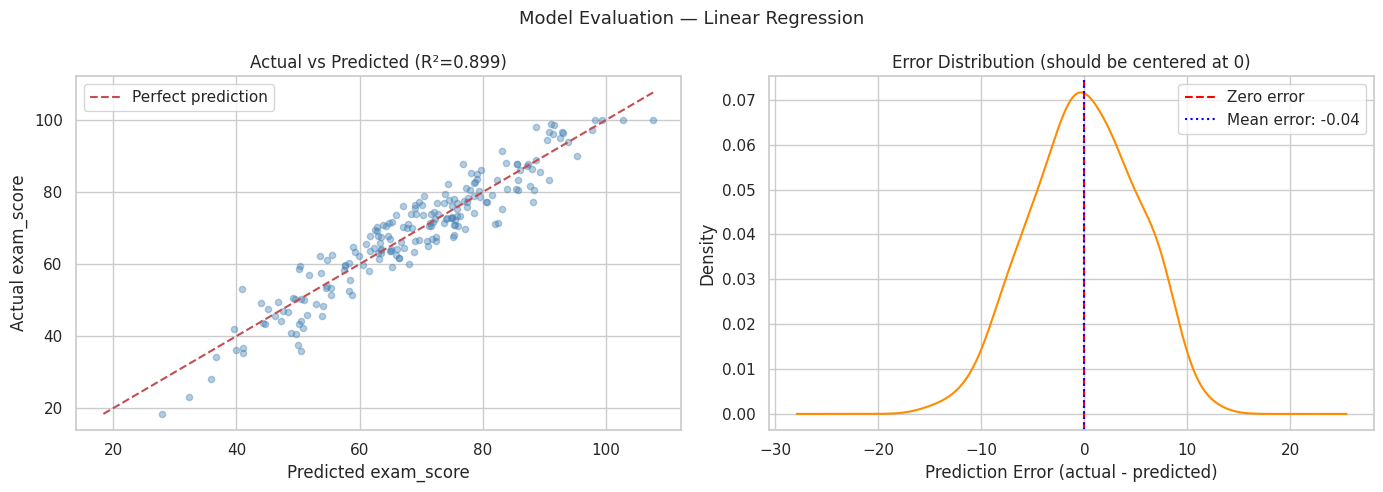

In [29]:
# ── 9.3 Regression Evaluation Plots ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
# If the model is perfect, all points lie on the red diagonal line
# The further from the diagonal, the worse the predictions
axes[0].scatter(y_pred_original, y_test_original, alpha=0.4, color='steelblue', s=20)
min_val = min(y_test_original.min(), y_pred_original.min())
max_val = max(y_test_original.max(), y_pred_original.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Predicted exam_score')
axes[0].set_ylabel('Actual exam_score')
axes[0].set_title(f'Actual vs Predicted (R²={R2:.3f})')
axes[0].legend()

# Plot 2: Error Distribution
# A well-behaved model has errors centered at 0 (no systematic bias)
# and normally distributed (bell-shaped)
pd.Series(errors).plot.density(ax=axes[1], color='darkorange')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
axes[1].axvline(errors.mean(), color='blue', linestyle=':', linewidth=1.5, label=f'Mean error: {errors.mean():.2f}')
axes[1].set_xlabel('Prediction Error (actual - predicted)')
axes[1].set_title('Error Distribution (should be centered at 0)')
axes[1].legend()

plt.suptitle('Model Evaluation — Linear Regression', fontsize=13)
plt.tight_layout()
plt.show()

---
## SECTION 10 — From-Scratch Implementation (Educational)

This section reimplements linear regression from scratch using **gradient descent**.
This is the CORRECT algorithm to show students — not the random walk from the original.

### What is Gradient Descent?
Imagine you're blindfolded on a hilly landscape and want to find the lowest valley.
In each step, you feel the slope of the ground beneath your feet and step in the
downhill direction. Gradient descent does exactly this — mathematically.

The 'slope' is the **gradient** (derivative) of the loss function.  
The 'step size' is the **learning rate** (α).

In [30]:
# ── 10.1 Define Loss Function ───────────────────────────────────────────────
def loss_mse(y_true, y_pred):
    """Mean Squared Error: average of squared differences between actual and predicted."""
    errors = y_true - y_pred
    return (errors ** 2).mean()

def loss_mae(y_true, y_pred):
    """Mean Absolute Error: average of absolute differences."""
    errors = y_true - y_pred
    return np.abs(errors).mean()

In [31]:
# ── 10.2 Gradient Descent Optimizer ────────────────────────────────────────
# ✅ IMPROVED: Using GRADIENT DESCENT instead of random walk ('Bayesian')
#
# For MSE loss: the gradient tells us exactly how to adjust each beta
#   dL/dβⱼ = -2/n × Σ(yᵢ - ŷᵢ) × xᵢⱼ
#
# We move each beta OPPOSITE to the gradient (downhill)
#   β_new = β_old - learning_rate × gradient

def gradient_descent_step(X, y_true, beta0, betas, learning_rate=0.01):
    """
    Perform one gradient descent update step.
    Returns updated (beta0, betas).
    """
    n = len(y_true)
    y_pred = beta0 + X.dot(betas)      # Current prediction
    errors = y_true - y_pred           # How wrong we are for each sample

    # Gradient for the intercept (bias term)
    grad_beta0 = -2/n * errors.sum()

    # Gradient for each feature coefficient
    grad_betas = -2/n * X.T.dot(errors)

    # Update: move OPPOSITE to gradient (downhill)
    beta0_new = beta0 - learning_rate * grad_beta0
    betas_new = betas - learning_rate * grad_betas

    return beta0_new, betas_new

In [32]:
# ── 10.3 Training Loop with Gradient Descent ────────────────────────────────
# ✅ Much fewer iterations needed (1000 vs 100,000) because gradient descent
#    moves in the OPTIMAL direction, not a random one

np.random.seed(RANDOM_STATE)  # Reproducibility

# Initialize parameters with small random values
beta0_gd = np.random.normal(0, 0.01)
betas_gd = np.random.normal(0, 0.01, len(FEATURE_COLS))

X_train_np = X_train_scaled.values  # Convert to numpy array for speed
y_train_np = y_train_scaled         # Already a numpy array

N_EPOCHS = 2000        # Number of full passes through the data
LEARNING_RATE = 0.05   # Step size — if too large: oscillates; if too small: slow
LOG_EVERY = 200        # Print progress every N epochs

loss_history = []  # Track loss over time to visualize learning

for epoch in range(N_EPOCHS):
    beta0_gd, betas_gd = gradient_descent_step(
        X_train_np, y_train_np, beta0_gd, betas_gd, LEARNING_RATE
    )

    y_pred = beta0_gd + X_train_np.dot(betas_gd)
    current_loss = loss_mse(y_train_np, y_pred)
    loss_history.append(current_loss)

    if epoch % LOG_EVERY == 0:
        print(f"Epoch {epoch:4d} | MSE: {current_loss:.6f}")

print(f"\n✅ Final MSE after {N_EPOCHS} epochs: {loss_history[-1]:.6f}")

Epoch    0 | MSE: 0.844938
Epoch  200 | MSE: 0.098633
Epoch  400 | MSE: 0.098633
Epoch  600 | MSE: 0.098633
Epoch  800 | MSE: 0.098633
Epoch 1000 | MSE: 0.098633
Epoch 1200 | MSE: 0.098633
Epoch 1400 | MSE: 0.098633
Epoch 1600 | MSE: 0.098633
Epoch 1800 | MSE: 0.098633

✅ Final MSE after 2000 epochs: 0.098633


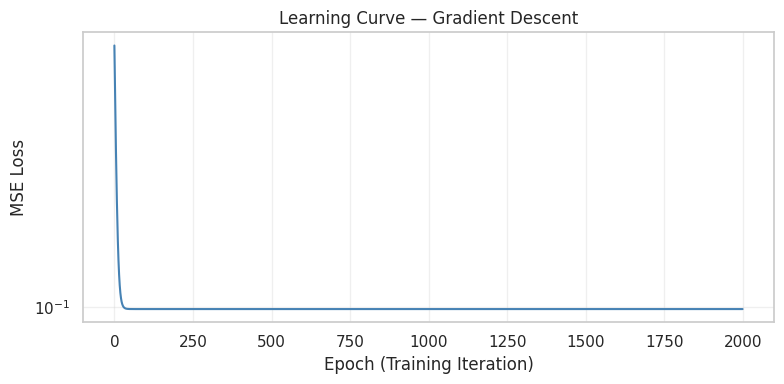

In [33]:
# ── 10.4 Plot Learning Curve ────────────────────────────────────────────────
# The learning curve shows how the loss decreases over training
# It SHOULD decrease quickly at first, then flatten out (convergence)
# If it goes UP, your learning rate is too high
# If it barely moves, your learning rate is too low

plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue')
plt.xlabel('Epoch (Training Iteration)')
plt.ylabel('MSE Loss')
plt.title('Learning Curve — Gradient Descent')
plt.yscale('log')  # Log scale makes it easier to see the convergence
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# ── 10.5 Compare: Scratch vs sklearn ────────────────────────────────────────
# Let's compare our from-scratch model with sklearn's optimal solution

# Predictions from our gradient descent model
y_pred_gd_scaled = beta0_gd + X_test_scaled.values.dot(betas_gd)
y_pred_gd_original = scaler_y.inverse_transform(y_pred_gd_scaled.reshape(-1, 1)).flatten()

mse_scratch = loss_mse(y_test_original, y_pred_gd_original)
mse_sklearn = metrics.mean_squared_error(y_test_original, y_pred_original)
r2_scratch = metrics.r2_score(y_test_original, y_pred_gd_original)
r2_sklearn = metrics.r2_score(y_test_original, y_pred_original)

print("Model Comparison (Test Set):")
print(f"{'Model':<30} {'MSE':>10} {'RMSE':>10} {'R²':>10}")
print("-" * 65)
print(f"{'From-Scratch (Grad. Descent)':<30} {mse_scratch:>10.4f} {mse_scratch**0.5:>10.4f} {r2_scratch:>10.4f}")
print(f"{'Sklearn LinearRegression':<30} {mse_sklearn:>10.4f} {mse_sklearn**0.5:>10.4f} {r2_sklearn:>10.4f}")
print("\nNote: Sklearn uses the exact analytical solution — the theoretical optimum.")
print("Our gradient descent approximates it and could match with more epochs.")

Model Comparison (Test Set):
Model                                 MSE       RMSE         R²
-----------------------------------------------------------------
From-Scratch (Grad. Descent)      25.9194     5.0911     0.8989
Sklearn LinearRegression          25.9194     5.0911     0.8989

Note: Sklearn uses the exact analytical solution — the theoretical optimum.
Our gradient descent approximates it and could match with more epochs.


---
## SECTION 11 — Key Takeaways & ML Roadmap

### What We Covered
1. **EDA**: Always explore your data before modeling
2. **Encoding**: ML needs numbers — convert categories appropriately
3. **Train/Test Split**: NEVER evaluate on training data
4. **Scaling**: Put all features on the same scale
5. **Linear Regression**: Learn the relationship between features and target
6. **Loss Functions**: Measure how wrong the model is (MSE, MAE, RMSE, R²)
7. **Gradient Descent**: How models learn (move toward lower loss)

### Next Steps: ML Model Landscape

#### Regression Models (predicting a number)
- **Linear Regression** ← what we just did
- **Ridge / Lasso / ElasticNet** ← linear regression + regularization (prevents overfitting)
- **Decision Tree / Random Forest** ← non-linear, handles complex patterns
- **Gradient Boosting (XGBoost)** ← state of the art for tabular data

#### Classification Models (predicting a category, e.g. pass/fail)
- **Logistic Regression** ← linear, predicts probability
- **Decision Tree / Random Forest** ← rule-based
- **SVM** ← finds the best decision boundary
- **XGBoost** ← wins most Kaggle competitions

#### Deep Learning (Neural Networks)
- **Dense layers**: Basic building blocks
- **CNN**: For images
- **RNN/LSTM**: For sequences and time series
- **Transformers**: For language (GPT, BERT, etc.)

In [35]:
# ── Final Summary Cell ──────────────────────────────────────────────────────
print("═" * 60)
print("FINAL MODEL SUMMARY")
print("═" * 60)
print(f"Dataset:       {len(students)} students, {len(FEATURE_COLS)} features")
print(f"Train/Test:    {len(X_train)}/{len(X_test)} students")
print(f"Algorithm:     Linear Regression (sklearn)")
print(f"Target:        exam_score")
print("─" * 60)
print(f"R²:   {r2_sklearn:.4f}  → model explains {r2_sklearn*100:.1f}% of score variance")
print(f"RMSE: {mse_sklearn**0.5:.2f}  → predictions off by ~{mse_sklearn**0.5:.1f} points on average")
print(f"MAE:  {metrics.mean_absolute_error(y_test_original, y_pred_original):.2f}  → average absolute error")
print("═" * 60)

════════════════════════════════════════════════════════════
FINAL MODEL SUMMARY
════════════════════════════════════════════════════════════
Dataset:       1000 students, 15 features
Train/Test:    800/200 students
Algorithm:     Linear Regression (sklearn)
Target:        exam_score
────────────────────────────────────────────────────────────
R²:   0.8989  → model explains 89.9% of score variance
RMSE: 5.09  → predictions off by ~5.1 points on average
MAE:  4.14  → average absolute error
════════════════════════════════════════════════════════════
